In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_columns')
#pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

# EDA

Investigar as correlacoes de pelo menos 70% e avaliar como remove-las.
Pesquisar se 70% e um valor razoavel para considerar ou se precisa ser menor ou maior

In [2]:
df_treino = pd.read_csv('train.csv')
df_treino = df_treino.drop(['Id'],axis=1)
df_treino

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,

In [3]:
df_treino.shape

(1460, 80)

In [4]:
#df_treino.dtypes
df_treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [5]:
df_treino.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [6]:
#df_treino.corr()
pd.set_option('display.max_rows', None)

df_treino.isnull().sum()
#pd.reset_option('display.max_rows')

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

In [7]:
#type(df_treino.isnull().sum())
#n type(df_treino.dtypes)

#pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')
df_treino.nunique()


MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
Street              2
Alley               2
LotShape            4
LandContour         4
Utilities           2
LotConfig           5
LandSlope           3
Neighborhood       25
Condition1          9
Condition2          8
BldgType            5
HouseStyle          8
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
RoofStyle           6
RoofMatl            8
Exterior1st        15
Exterior2nd        16
MasVnrType          3
MasVnrArea        327
ExterQual           4
ExterCond           5
Foundation          6
BsmtQual            4
BsmtCond            4
BsmtExposure        4
BsmtFinType1        6
BsmtFinSF1        637
BsmtFinType2        6
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
Heating             6
HeatingQC           5
CentralAir          2
Electrical          5
1stFlrSF          753
2ndFlrSF          417
LowQualFinSF       24
GrLivArea 

## Variaveis Numéricas

In [8]:
pd.reset_option('display.max_rows')
df_treino_numericas = df_treino.select_dtypes(['int64','float64'])
df_treino_numericas
#df_treino_numericas.sort_values(by='LotFrontage')


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,953,953,953,694,0,1647,0,0,2,1,3,1,7,1,1999.0,2,460,0,40,0,0,0,0,0,8,2007,175000
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,589,1542,2073,0,0,2073,1,0,2,0,3,1,7,2,1978.0,2,500,349,0,0,0,0,0,0,2,2010,210000
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,877,1152,1188,1152,0,2340,0,0,2,0,4,1,9,2,1941.0,1,252,0,60,0,0,0,0,2500,5,2010,266500
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,0,1078,1078,0,0,1078,1,0,1,0,2,1,5,0,1950.0,1,240,366,0,112,0,0,0,0,4,2010,142125


### Correlação entre variáveis numéricas

Podemos ver uma correlacao consideravel entre:
As variaveis de garagem;
As variaveis de TotalBsmtSF e 1stFlrSF;
Avaliar relacoes

<Axes: >

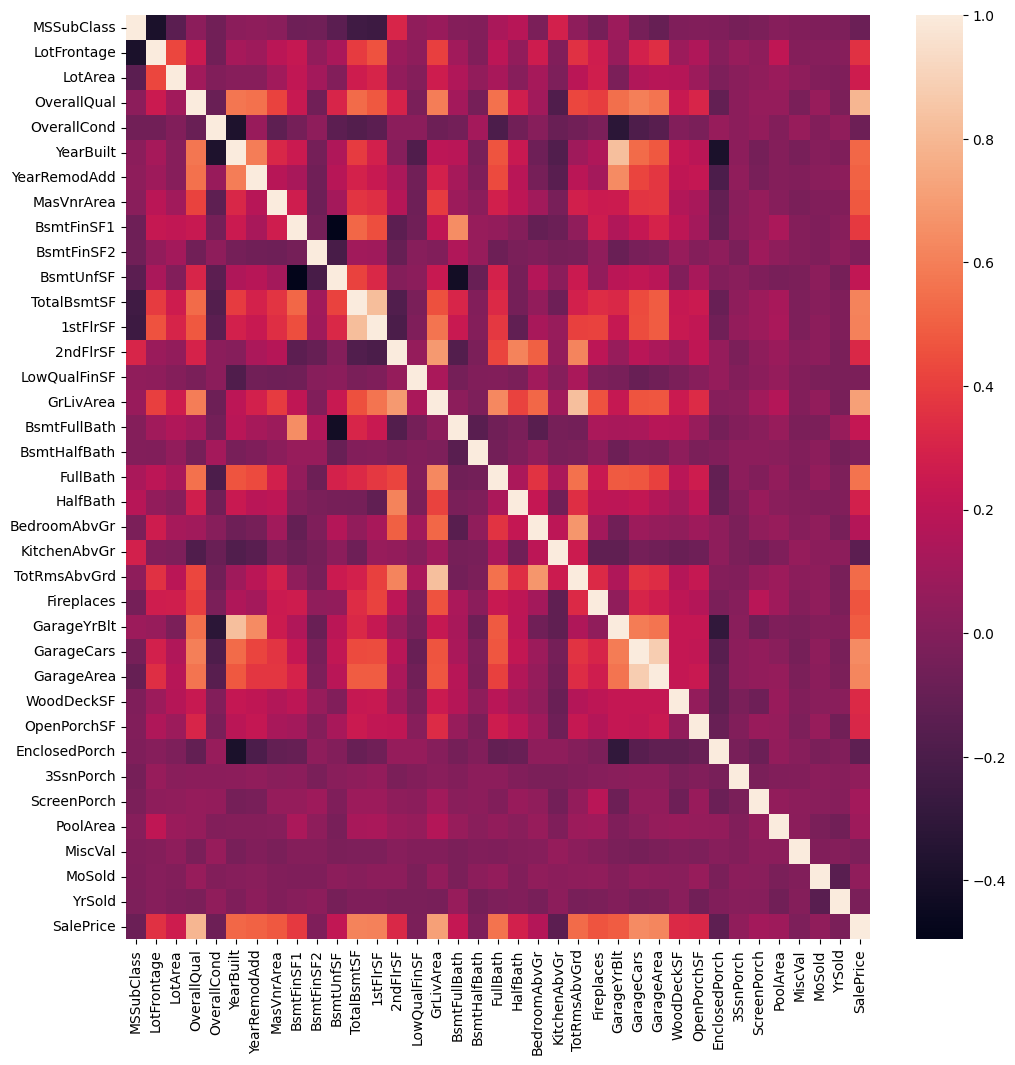

In [9]:
#df_treino.select_dtypes(['int64','float64']).drop(['Id'],axis=1).corr()
plt.figure(figsize=(12,12))
sns.heatmap(df_treino_numericas.corr())

Podemos ver uma correlacao consideravel (>70%) entre:
SalePrice e OverallQual (0.79);
SalePrice e GrLivArea (0.70);
YearBuilt e GarageYrBlt (0.82);
TotalBsmtSF e 1stFlrSF (0.81);
GrLivArea e TotRmsAbvGrd (0.82);


In [10]:
df_treino_numericas_corr = df_treino_numericas.corr()

taxa_relevancia = 0.7

df_treino_numericas_corr_relevantes = df_treino_numericas_corr[
    ((df_treino_numericas_corr > taxa_relevancia) & (df_treino_numericas_corr < 1))
    |((df_treino_numericas_corr < -taxa_relevancia) & (df_treino_numericas_corr > -1))]
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True)
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True,axis=1)
df_treino_numericas_corr_relevantes

,OverallQual,YearBuilt,TotalBsmtSF,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageYrBlt,GarageCars,GarageArea,SalePrice
OverallQual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.790982
YearBuilt,NaN,NaN,NaN,NaN,NaN,NaN,0.825667,NaN,NaN,NaN
TotalBsmtSF,NaN,NaN,NaN,0.81953,NaN,NaN,NaN,NaN,NaN,NaN
1stFlrSF,NaN,NaN,0.81953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GrLivArea,NaN,NaN,NaN,NaN,NaN,0.825489,NaN,NaN,NaN,0.708624
TotRmsAbvGrd,NaN,NaN,NaN,NaN,0.825489,NaN,NaN,NaN,NaN,NaN
GarageYrBlt,NaN,0.825667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GarageCars,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.882475,NaN
GarageArea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.882475,NaN,NaN
SalePrice,0.790982,NaN,NaN,NaN,0.708624,NaN,NaN,NaN,NaN,NaN


### SalePrice Feature Analysis

Vale a pena investigar os casos em que a correlacao esta acima de 70%:
OverallQual;
GrLivArea;

In [11]:
df_treino_numericas.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePrice, dtype: float64

#### GrLivArea feature: corr de 70% com SalePrice

Alta correlacao com TotRmsAbvGrd

In [12]:
df_treino_numericas.corr()['GrLivArea'].sort_values()

OverallCond     -0.079686
YrSold          -0.036526
BsmtHalfBath    -0.018918
BsmtFinSF2      -0.009640
MiscVal         -0.002416
EnclosedPorch    0.009113
3SsnPorch        0.020643
BsmtFullBath     0.034836
MoSold           0.050240
MSSubClass       0.074853
KitchenAbvGr     0.100063
ScreenPorch      0.101510
LowQualFinSF     0.134683
PoolArea         0.170205
YearBuilt        0.199010
BsmtFinSF1       0.208171
GarageYrBlt      0.231197
BsmtUnfSF        0.240257
WoodDeckSF       0.247433
LotArea          0.263116
YearRemodAdd     0.287389
OpenPorchSF      0.330224
MasVnrArea       0.390857
LotFrontage      0.402797
HalfBath         0.415772
TotalBsmtSF      0.454868
Fireplaces       0.461679
GarageCars       0.467247
GarageArea       0.468997
BedroomAbvGr     0.521270
1stFlrSF         0.566024
OverallQual      0.593007
FullBath         0.630012
2ndFlrSF         0.687501
SalePrice        0.708624
TotRmsAbvGrd     0.825489
GrLivArea        1.000000
Name: GrLivArea, dtype: float64

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

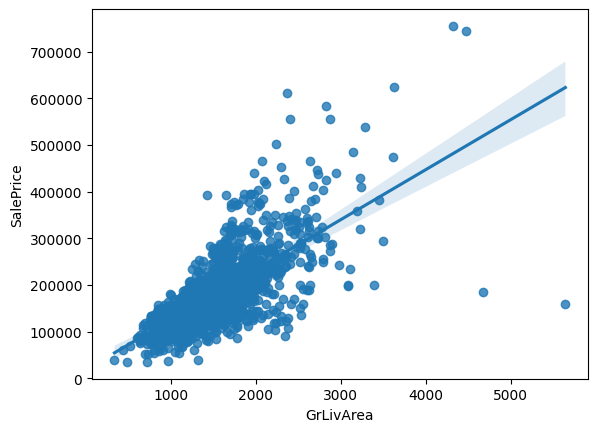

In [13]:
#sns.scatterplot(df_treino_numericas,x='GrLivArea',y='SalePrice')
sns.regplot(df_treino_numericas,x='GrLivArea',y='SalePrice')

#### OverallQual feature: corr de 79% com SalePrice

In [14]:
df_treino_numericas.corr()['OverallQual'].sort_values()

KitchenAbvGr    -0.183882
EnclosedPorch   -0.113937
OverallCond     -0.091932
BsmtFinSF2      -0.059119
BsmtHalfBath    -0.040150
MiscVal         -0.031406
LowQualFinSF    -0.030429
YrSold          -0.027347
3SsnPorch        0.030371
MSSubClass       0.032628
ScreenPorch      0.064886
PoolArea         0.065166
MoSold           0.070815
BedroomAbvGr     0.101676
LotArea          0.105806
BsmtFullBath     0.111098
WoodDeckSF       0.238923
BsmtFinSF1       0.239666
LotFrontage      0.251646
HalfBath         0.273458
2ndFlrSF         0.295493
BsmtUnfSF        0.308159
OpenPorchSF      0.308819
Fireplaces       0.396765
MasVnrArea       0.411876
TotRmsAbvGrd     0.427452
1stFlrSF         0.476224
TotalBsmtSF      0.537808
GarageYrBlt      0.547766
FullBath         0.550600
YearRemodAdd     0.550684
GarageArea       0.562022
YearBuilt        0.572323
GrLivArea        0.593007
GarageCars       0.600671
SalePrice        0.790982
OverallQual      1.000000
Name: OverallQual, dtype: float64

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

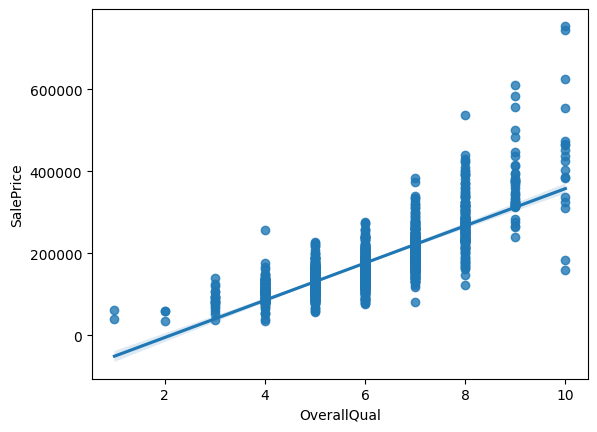

In [15]:
#sns.scatterplot(df_treino_numericas,x='OverallQual',y='SalePrice')
sns.regplot(df_treino_numericas,x='OverallQual',y='SalePrice')

### Pool feature analysis


PoolArea: Pool area in square feet

PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool

Maior parte das casas nao possui piscina.
Nao ha nenhuma piscina com a categoria de qualidade "TA	Average/Typical"

In [16]:
df_treino['PoolQC'].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

<Axes: xlabel='PoolQC', ylabel='count'>

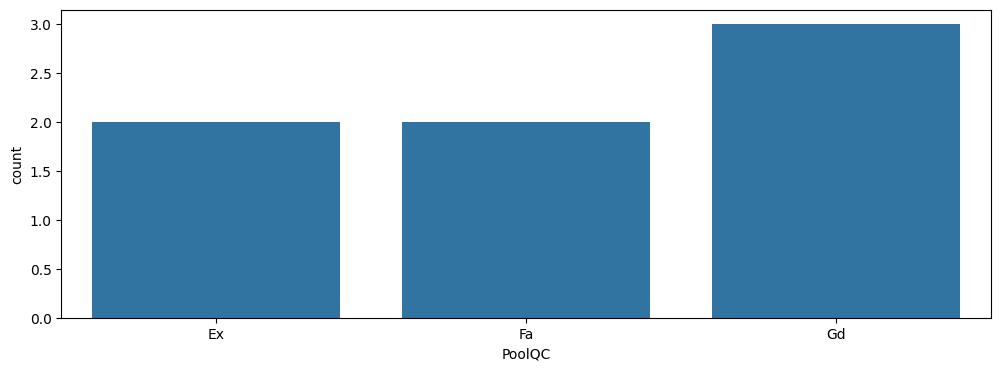

In [17]:
#df_treino['PoolQC']
plt.figure(figsize=(12,4))
sns.countplot(df_treino,x='PoolQC')

Correlação alta entre PoolArea e as variáveis Dummy

In [18]:
#df_treino_numericas.corr()['PoolArea'].sort_values()
df_poolqc_dummies = pd.get_dummies(df_treino['PoolQC'],dummy_na=True,dtype=float,prefix='PollQc')
#df_poolqc_dummies

df_teste_pool = pd.concat([df_treino_numericas,df_poolqc_dummies],axis=1)
df_teste_pool

df_teste_pool.corr()['PoolArea'].sort_values()
#df_treino['PoolQC'].value_counts()

PollQc_nan      -0.989665
YrSold          -0.059689
BsmtUnfSF       -0.035092
MoSold          -0.033737
KitchenAbvGr    -0.014525
GarageYrBlt     -0.014501
3SsnPorch       -0.007992
OverallCond     -0.001985
YearBuilt        0.004950
YearRemodAdd     0.005829
MSSubClass       0.008283
MasVnrArea       0.011723
BsmtHalfBath     0.020025
GarageCars       0.020934
HalfBath         0.022381
MiscVal          0.029669
BsmtFinSF2       0.041709
FullBath         0.049604
ScreenPorch      0.051307
EnclosedPorch    0.054203
OpenPorchSF      0.060762
GarageArea       0.061047
LowQualFinSF     0.062157
OverallQual      0.065166
BsmtFullBath     0.067616
BedroomAbvGr     0.070703
WoodDeckSF       0.073378
LotArea          0.077672
2ndFlrSF         0.081487
TotRmsAbvGrd     0.083757
SalePrice        0.092404
Fireplaces       0.095074
TotalBsmtSF      0.126053
1stFlrSF         0.131525
BsmtFinSF1       0.140491
GrLivArea        0.170205
LotFrontage      0.206167
PollQc_Ex        0.489426
PollQc_Fa   

Correlação altissima entre PoolArea e PollQc_nan. 
Vale a pena fazer o drop de PollQc_nan

In [19]:
df_pool = pd.concat([df_treino_numericas['PoolArea'],df_poolqc_dummies],axis=1)
df_pool

df_pool.corr()
#sns.heatmap(df_pool.corr())

,PoolArea,PollQc_Ex,PollQc_Fa,PollQc_Gd,PollQc_nan
PoolArea,1.000000,0.489426,0.535534,0.672499,-0.989665
PollQc_Ex,0.489426,1.000000,-0.001372,-0.001681,-0.533605
PollQc_Fa,0.535534,-0.001372,1.000000,-0.001681,-0.533605
PollQc_Gd,0.672499,-0.001681,-0.001681,1.000000,-0.653754
PollQc_nan,-0.989665,-0.533605,-0.533605,-0.653754,1.000000


<Axes: >

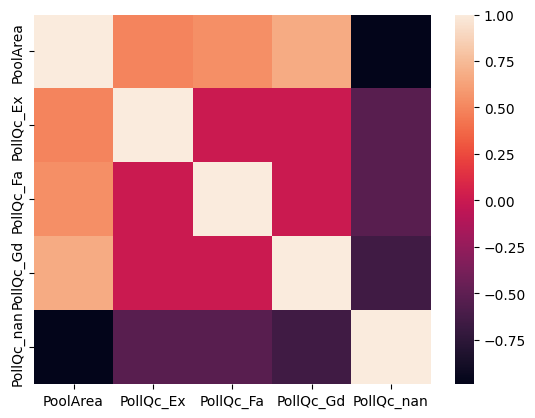

In [20]:
sns.heatmap(df_pool.corr())

Porem nao ha correlacao alta entre SalePrice e as features de Pool

In [21]:
df_pool_price = pd.concat([df_treino_numericas['SalePrice'],df_pool],axis=1)
#df_pool_price
df_pool_price.corr()['SalePrice']

SalePrice     1.000000
PoolArea      0.092404
PollQc_Ex     0.144146
PollQc_Fa     0.016127
PollQc_Gd     0.012038
PollQc_nan   -0.093708
Name: SalePrice, dtype: float64

### Garage Feature Analysis

GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage

PavedDrive: Paved driveway

       Y	Paved 
       P	Partial Pavement
       N	Dirt/Gravel


### Basement Feature Analysis

Foundation: Type of foundation
		
       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Contrete	
       Slab	Slab
       Stone	Stone
       Wood	Wood
		
BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
	
BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area


### Porch feature analysis

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet


## Variáveis categóricas

In [22]:
#df_treino.select_dtypes(['str']).columns
df_treino_categoricas = df_treino[['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition']]
#sns.scatterplot(df_treino_categoricas,x='Street',y='SalePrice')
#plt.figure(figsize=(12,12))
#sns.heatmap(df_treino.select_dtypes(['int64','float64']).drop(['Id',],axis=1).corr())
df_treino_categoricas.shape

(1460, 43)

In [23]:
#df_treino_categoricas[df_treino_categoricas['Street'] == 'Grvl']

### Avaliar correlacao entre variaveis dummys das variaveis categoricas

Considerando a correlacao de pelo menos 70%
82 casos encontrados entre as variaveis dummy (levando em consideração os nan). Mas vários casos são de variáveis dummys de variáveis categóricas binarias, ou seja, um dropfirst omitiria estes casos, caindo assim para 61 casos

Nem todas as variáveis categóricas possuem valores nulos. Vale a pena criar os dummy_na apenas nos casos em que há valores nulos

In [24]:
df_treino_categoricas.isnull().sum()

MSZoning            0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1453
Fence            1179
MiscFeature      1406
SaleType            0
SaleCondition       0
dtype: int64

In [25]:
#pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

df_categoricas_isnull_sum = df_treino_categoricas.isnull().sum()
df_categoricas_has_null = df_categoricas_isnull_sum[df_categoricas_isnull_sum>0].index
df_categoricas_not_has_null = df_categoricas_isnull_sum[df_categoricas_isnull_sum==0].index

In [26]:
df_categoricas_has_null_dummies = pd.get_dummies(df_treino_categoricas[df_categoricas_has_null],dtype=float,dummy_na=True)
df_categoricas_not_has_null_dummies = pd.get_dummies(df_treino_categoricas[df_categoricas_not_has_null],dtype=float)
df_treino_categoricas_dummies = pd.concat([df_categoricas_has_null_dummies,df_categoricas_not_has_null_dummies],axis=1)
df_treino_categoricas_dummies

,Alley_Grvl,Alley_Pave,Alley_nan,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,MasVnrType_nan,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtQual_nan,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtCond_nan,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_nan,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType1_nan,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,BsmtFinType2_nan,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Electrical_nan,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,FireplaceQu_nan,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_nan,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageFinish_nan,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageQual_nan,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,GarageCond_nan,PoolQC_Ex,PoolQC_Fa,PoolQC_Gd,PoolQC_nan,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_nan,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_nan,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2

In [27]:
pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

#df_treino_categoricas_dummies = pd.concat([df_categoricas_has_null_dummies,df_categoricas_not_has_null_dummies],axis=1)
df_treino_categoricas_dummies_price = pd.concat([df_treino['SalePrice'],df_treino_categoricas_dummies],axis=1)
#df_treino_categoricas_dummies_corr = df_treino_categoricas_dummies.corr()
df_treino_categoricas_dummies_corr = df_treino_categoricas_dummies_price.corr()


A correlação mais alta de SalePrice está com algumas variaves de Basement, Kitchem e ExterQUal. Na faixa de 50%

In [28]:
taxa_relevancia = 0.5
df_treino_categoricas_dummies_corr['SalePrice'][
    (df_treino_categoricas_dummies_corr['SalePrice']>taxa_relevancia)
    | (df_treino_categoricas_dummies_corr['SalePrice']<-taxa_relevancia)]

SalePrice         1.000000
BsmtQual_Ex       0.553105
ExterQual_TA     -0.589044
KitchenQual_Ex    0.504094
KitchenQual_TA   -0.519298
Name: SalePrice, dtype: float64

Considerando a correlacao de pelo menos 70%
82 casos encontrados entre as variaveis dummy (levando em consideração os nan). 
Mas vários casos são de variáveis dummys de variáveis categóricas binarias, 
ou seja, um dropfirst omitiria estes casos, caindo assim para 61 casos. Por exemplo: PaveDrive_N e PaveDrive_Y

In [29]:
pd.reset_option('display.max_rows')

df_treino_categoricas_dummies_corr_relevantes = df_treino_categoricas_dummies_corr[
    ((df_treino_categoricas_dummies_corr > 0.7) & (df_treino_categoricas_dummies_corr < 1))
    |((df_treino_categoricas_dummies_corr < -0.7) & (df_treino_categoricas_dummies_corr > -1))]
df_treino_categoricas_dummies_corr_relevantes.dropna(how='all',inplace=True)
df_treino_categoricas_dummies_corr_relevantes.dropna(how='all',inplace=True,axis=1)
df_treino_categoricas_dummies_corr_relevantes

,Alley_Grvl,Alley_nan,MasVnrType_BrkFace,MasVnrType_nan,BsmtQual_Gd,BsmtQual_TA,BsmtQual_nan,BsmtCond_Po,BsmtCond_nan,BsmtExposure_nan,BsmtFinType1_nan,BsmtFinType2_nan,Electrical_FuseA,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Detchd,GarageType_nan,GarageFinish_nan,GarageQual_Ex,GarageQual_TA,GarageQual_nan,GarageCond_Ex,GarageCond_TA,GarageCond_nan,PoolQC_Fa,Fence_MnPrv,Fence_nan,MiscFeature_Gar2,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_nan,MSZoning_FV,MSZoning_RL,MSZoning_RM,LotShape_IR1,LotShape_Reg,LotConfig_Corner,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,Neighborhood_Somerst,Condition2_RRAe,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Hip,RoofStyle_Shed,RoofMatl_Tar&Grv,Exterior1st_AsbShng,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior2nd_AsbShng,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Heating_GasA,Heating_GasW,CentralAir_N,CentralAir_Y,KitchenQual_Gd,KitchenQual_TA,PavedDrive_N,PavedDrive_Y,SaleType_New,SaleType_WD,SaleCondition_Partial
Alley_Grvl,NaN,-0.730393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley_nan,-0.730393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MasVnrType_BrkFace,NaN,NaN,NaN,-0.806337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MasVnrType_nan,NaN,NaN,-0.806337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BsmtQual_Gd,NaN,NaN,NaN,NaN,NaN,-0.766391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PavedDrive_N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.856491,NaN,NaN,NaN
PavedDrive_Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [30]:
df_treino_categoricas_dummies_corr_relevantes.columns

Index(['Alley_Grvl', 'Alley_nan', 'MasVnrType_BrkFace', 'MasVnrType_nan',
       'BsmtQual_Gd', 'BsmtQual_TA', 'BsmtQual_nan', 'BsmtCond_Po',
       'BsmtCond_nan', 'BsmtExposure_nan', 'BsmtFinType1_nan',
       'BsmtFinType2_nan', 'Electrical_FuseA', 'Electrical_Mix',
       'Electrical_SBrkr', 'GarageType_Attchd', 'GarageType_Detchd',
       'GarageType_nan', 'GarageFinish_nan', 'GarageQual_Ex', 'GarageQual_TA',
       'GarageQual_nan', 'GarageCond_Ex', 'GarageCond_TA', 'GarageCond_nan',
       'PoolQC_Fa', 'Fence_MnPrv', 'Fence_nan', 'MiscFeature_Gar2',
       'MiscFeature_Shed', 'MiscFeature_TenC', 'MiscFeature_nan',
       'MSZoning_FV', 'MSZoning_RL', 'MSZoning_RM', 'LotShape_IR1',
       'LotShape_Reg', 'LotConfig_Corner', 'LotConfig_Inside', 'LandSlope_Gtl',
       'LandSlope_Mod', 'Neighborhood_Somerst', 'Condition2_RRAe',
       'RoofStyle_Flat', 'RoofStyle_Gable', 'RoofStyle_Hip', 'RoofStyle_Shed',
       'RoofMatl_Tar&Grv', 'Exterior1st_AsbShng', 'Exterior1st_CemntBd',
    

In [31]:
# TODO: trabalhar visualização da matriz esparsa - df_treino_categoricas_dummies_corr_relevantes

pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

#colum_index = df_treino_categoricas_dummies_corr_relevantes.columns[0]
#a = df_treino_categoricas_dummies_corr_relevantes[colum_index].dropna()
#b = df_treino_categoricas_dummies_corr_relevantes.columns[1]
#df_dummy_categ_value = pd.Series()
#df_dummy_categ_value = pd.concat([df_dummy_categ_value,a])
#df_dummy_categ_value = df_treino_categoricas_dummies_corr_relevantes[a].dropna()
#df_dummy_categ_value = df_treino_categoricas_dummies_corr_relevantes[b].dropna()
#type(df_dummy_categ_value)
#df_dummy_categ_value

for categ in df_treino_categoricas_dummies_corr_relevantes:
    print(categ)
    corr_column = df_treino_categoricas_dummies_corr_relevantes[categ].dropna()
    print(corr_column.index, corr_column.values)
    #print(corr_column)
    print("----------------------------")

Alley_Grvl
Index(['Alley_nan'], dtype='str') [-0.73039278]
----------------------------
Alley_nan
Index(['Alley_Grvl'], dtype='str') [-0.73039278]
----------------------------
MasVnrType_BrkFace
Index(['MasVnrType_nan'], dtype='str') [-0.80633695]
----------------------------
MasVnrType_nan
Index(['MasVnrType_BrkFace'], dtype='str') [-0.80633695]
----------------------------
BsmtQual_Gd
Index(['BsmtQual_TA'], dtype='str') [-0.7663905]
----------------------------
BsmtQual_TA
Index(['BsmtQual_Gd'], dtype='str') [-0.7663905]
----------------------------
BsmtQual_nan
Index(['BsmtExposure_nan', 'BsmtFinType2_nan', 'Foundation_Slab'], dtype='str') [0.9864076  0.9864076  0.80173342]
----------------------------
BsmtCond_Po
Index(['Electrical_Mix'], dtype='str') [0.70686441]
----------------------------
BsmtCond_nan
Index(['BsmtExposure_nan', 'BsmtFinType2_nan', 'Foundation_Slab'], dtype='str') [0.9864076  0.9864076  0.80173342]
----------------------------
BsmtExposure_nan
Index(['BsmtQual_n

In [32]:
df_treino_categoricas_dummies_corr_relevantes.shape

(82, 82)

### Avaliar similaridades entre Street, Alley e Fence

### Electrical feature analysis

Utilities: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only	

Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed


### Heating feature analysis

### Central Air feature analysis

Essa feature é binária, talvez seja suficiente simplesmente dropar uma das duas

### Kitchen feature analysis

### Lot feature analysis

LotFrontage: Linear feet of street connected to property

LotArea: Lot size in square feet

LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression

LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope

### Neighborhood feature analysis

Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
			
Condition1: Proximity to various conditions
	
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
Condition2: Proximity to various conditions (if more than one is present)
		
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad

### Roof feature analysis


RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed
		
RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles
		

### Exterior feature analysis

		
Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast	
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor


### sales feature analysis

Será que eu deveria juntar as features de construction junto com a de sales?

MoSold: Month Sold (MM)

YrSold: Year Sold (YYYY)

SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other
		
SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)


### misc feature analysis

MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
MiscVal: $Value of miscellaneous feature

### Avaliar similaridades entre OverallQual e OverallCond

### area above grade analysis

1stFlrSF: First Floor square feet
 
2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

Bedroom: Bedrooms above grade (does NOT include basement bedrooms)

Kitchen: Kitchens above grade

KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       	
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)

### fireplaces feature analysis

Fireplaces: Number of fireplaces

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace

### dwelling feature analysis

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density

BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level

### other

YearBuilt: Original construction date

YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only

## Correlação considerando variáveis numéricas e as categóricas dummies

In [33]:
pd.reset_option('display.max_rows')
#df_treino_categoricas_dummies
#df_treino_numericas
df_treino_todas_variaveis = pd.concat([df_treino_numericas,df_treino_categoricas_dummies],axis=1)
#df_treino_todas_variaveis
df_treino_todas_variaveis_corr=df_treino_todas_variaveis.corr()
df_treino_todas_variaveis_corr
taxa_relevancia = 0.7

df_treino_todas_variaveis_corr_relevantes = df_treino_todas_variaveis_corr[
    ((df_treino_todas_variaveis_corr > taxa_relevancia) & (df_treino_todas_variaveis_corr < 1))
    |((df_treino_todas_variaveis_corr < -taxa_relevancia) & (df_treino_todas_variaveis_corr > -1))]
df_treino_todas_variaveis_corr_relevantes.dropna(how='all',inplace=True)
df_treino_todas_variaveis_corr_relevantes.dropna(how='all',inplace=True,axis=1)
df_treino_todas_variaveis_corr_relevantes

,MSSubClass,OverallQual,YearBuilt,BsmtFinSF2,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,PoolArea,MiscVal,SalePrice,Alley_Grvl,Alley_nan,MasVnrType_BrkFace,MasVnrType_nan,BsmtQual_Gd,BsmtQual_TA,BsmtQual_nan,BsmtCond_Po,BsmtCond_nan,BsmtExposure_nan,BsmtFinType1_nan,BsmtFinType2_Unf,BsmtFinType2_nan,Electrical_FuseA,Electrical_Mix,Electrical_SBrkr,FireplaceQu_nan,GarageType_Attchd,GarageType_Detchd,GarageType_nan,GarageFinish_nan,GarageQual_Ex,GarageQual_TA,GarageQual_nan,GarageCond_Ex,GarageCond_TA,GarageCond_nan,PoolQC_Fa,PoolQC_nan,Fence_MnPrv,Fence_nan,MiscFeature_Gar2,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_nan,MSZoning_FV,MSZoning_RL,MSZoning_RM,LotShape_IR1,LotShape_Reg,LotConfig_Corner,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,Neighborhood_Somerst,Condition2_RRAe,BldgType_1Fam,HouseStyle_1Story,HouseStyle_2Story,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Hip,RoofStyle_Shed,RoofMatl_Tar&Grv,Exterior1st_AsbShng,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior2nd_AsbShng,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Heating_GasA,Heating_GasW,CentralAir_N,CentralAir_Y,KitchenQual_Gd,KitchenQual_TA,PavedDrive_N,PavedDrive_Y,SaleType_New,SaleType_WD,SaleCondition_Partial
MSSubClass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.817461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OverallQual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.790982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearBuilt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.825667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BsmtFinSF2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.716235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,NaN,NaN,NaN,NaN,NaN,0.81953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [34]:
df_treino_todas_variaveis_corr_relevantes.shape

(104, 104)

Precisa avaliar se em algum caso há alta correlação entre alguma variável numérica e categórica

In [35]:
pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')
df_treino_todas_variaveis_corr_relevantes.isnull().sum()
#df_treino_todas_variaveis_corr_relevantes['GarageQual_TA']

MSSubClass               103
OverallQual              103
YearBuilt                103
BsmtFinSF2               103
TotalBsmtSF              103
1stFlrSF                 103
2ndFlrSF                 102
GrLivArea                102
TotRmsAbvGrd             103
Fireplaces               103
GarageYrBlt              103
GarageCars               103
GarageArea               103
PoolArea                 103
MiscVal                  103
SalePrice                102
Alley_Grvl               103
Alley_nan                103
MasVnrType_BrkFace       103
MasVnrType_nan           103
BsmtQual_Gd              103
BsmtQual_TA              103
BsmtQual_nan             101
BsmtCond_Po              103
BsmtCond_nan             101
BsmtExposure_nan          99
BsmtFinType1_nan         101
BsmtFinType2_Unf         103
BsmtFinType2_nan          99
Electrical_FuseA         103
Electrical_Mix           103
Electrical_SBrkr         103
FireplaceQu_nan          103
GarageType_Attchd        103
GarageType_Det

# Data pre processing

Muitas variáveis com alta correlação entre si. Para usar a regressão linear, se faz necessário uma Feature engineering pesada para avaliar, interpretar e combinar as variáveis dependentes. Talvez seja melhor usar RandomForestRegression ou GradientBoostingRegression

## Tratar valores nulos

## Tratar variaveis qualitativas - dummies variables

## Tratar variáveis com alta correlação

# model

## training model

## evaluating model